# **Idemia Datachallenge (IADATA704): Face Occlusion Prediction**

**Group Name:** Team GPU  
**Group Number:** 21  
**Team Members:** Oscar DE LA CRUZ, Rémi HAMON  

**Project repository:** [https://github.com/odelacruz-fierro/data-challenge-idemia.git](https://github.com/odelacruz-fierro/data-challenge-idemia.git)

---

In [47]:
import os
import pandas as pd
import matplotlib.pyplot as plt


from src import config


# Check files existence
files = [config.DF_TRAIN,
         config.DF_TEST,
         config.IMAGE_TEST]

for file in files:
    if os.path.exists(file):
        print(f"File O.k.! :\t{file}")
    else:
        print(f"File NOT O.k.! : {file}")

File O.k.! :	/home/mambo/Documents/data-challenge-idemia/data/raw/train.csv
File O.k.! :	/home/mambo/Documents/data-challenge-idemia/data/raw/test_students.csv
File O.k.! :	/home/mambo/Documents/data-challenge-idemia/data/raw/crops/Crop_224_5fp_100K/database1/img00000048.webp


## **Dataset overview**

In [34]:
df_train = pd.read_csv(config.DF_TRAIN, delimiter=',')
df_train = df_train.dropna()

df_test = pd.read_csv(config.DF_TEST, delimiter=',')
df_test = df_test.dropna()

In [18]:
df_train.info()
df_train.head()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   filename       100000 non-null  str    
 1   FaceOcclusion  100000 non-null  float64
 2   gender         100000 non-null  float64
dtypes: float64(2), str(1)
memory usage: 2.3 MB


,filename,FaceOcclusion,gender
0,database3/database3/m.01w0zk1/66-FaceId-0_alig...,0.024005,1.0
1,database3/database3/m.016ywr/88-FaceId-0_align...,0.030028,1.0
2,database3/database3/m.02dfmb/105-FaceId-0_alig...,0.009984,0.0
3,database3/database3/m.01_h_s/33-FaceId-5_align...,0.255016,1.0
4,database3/database3/m.02lqkv/85-FaceId-0_align...,0.252091,1.0


In [52]:
df_test.info()
df_test.head()

<class 'pandas.DataFrame'>
RangeIndex: 29980 entries, 0 to 29979
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   filename  29980 non-null  str  
dtypes: str(1)
memory usage: 234.3 KB


,filename
0,database3/database3/m.0256vn/81-FaceId-0_align...
1,database3/database3/m.01dgwg/29-FaceId-0_align...
2,database3/database3/m.02l0nk/72-FaceId-0_align...
3,database3/database3/m.026jp3/94-FaceId-1_align...
4,database3/database3/m.01ncgyv/24-FaceId-0_alig...


## **Occlusion distribution**

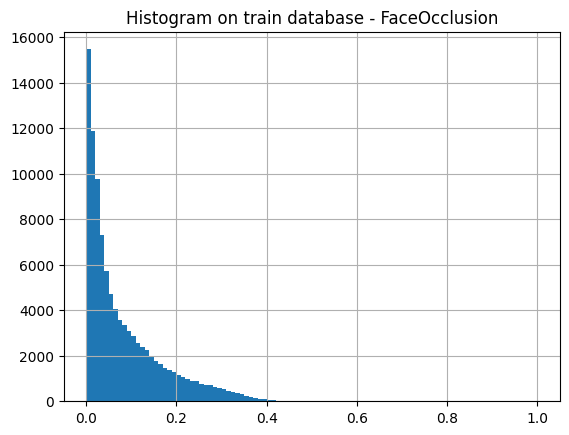

In [60]:
hist_occlusion = df_train.hist(column = ['FaceOcclusion'], bins = 100)
hist_occlusion[0,0].set_title("Histogram on train database - FaceOcclusion")
plt.savefig('report/figures/occlusion_distribution.pdf', bbox_inches='tight')
plt.show()

## **Gender distribution**

67.60 % are Men 
32.40 % are Women


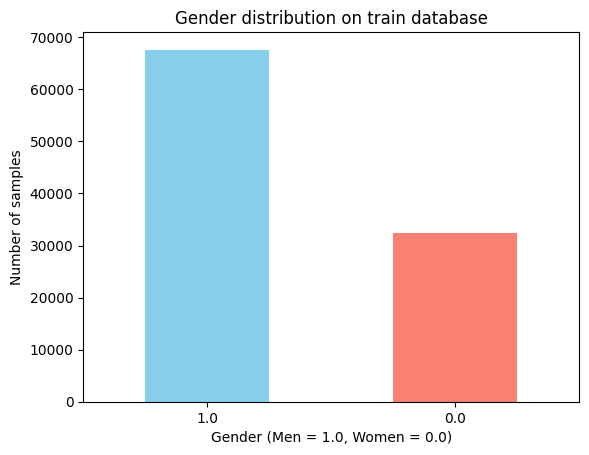

In [63]:
gender_counts = df_train['gender'].value_counts()

#print(gender_counts)
total = gender_counts.sum()
print(f"{(gender_counts[1]/total)*100:.2f} % are Men ")
print(f"{(gender_counts[0]/total)*100:.2f} % are Women")

gender_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Gender distribution on train database")
plt.xlabel("Gender (Men = 1.0, Women = 0.0)")
plt.ylabel("Number of samples")
plt.xticks(rotation=0) # Pour garder les labels horizontaux
plt.savefig('report/figures/gender_distribution.pdf', bbox_inches='tight')
plt.show()